In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys, os, h5py, time, psutil

import numpy as np
import healpy as hp
import tensorflow as tf

from tqdm import tqdm, trange
from sklearn.neighbors import BallTree

# from deepsphere.utils import split_sparse_dense_matmul

from msfm.grid_pipeline import GridPipeline

23-11-02 06:23:28   imports.py INF   Setting up healpy to run on 256 CPUs 
23-11-02 06:23:29   imports.py INF   Setting up healpy to run on 256 CPUs 


# constants

In [3]:
sigma_arcmin = 30
n_sigma_support = 3
sigma_rad = sigma_arcmin / 60 / 180 * np.pi

# example map

In [4]:
tfr_pattern = "/pscratch/sd/a/athomsen/DESY3/v5/linear_bias/tfrecords/grid/DESy3_grid_000.tfrecord"
conf = "/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v5/linear_bias.yaml"
params = ["Om", "s8", "Aia", "n_Aia", "bg", "n_bg"]

grid_pipe = GridPipeline(
    conf=conf,
    params=params,
    with_lensing=True,
    with_clustering=False,
    with_padding=True,
    apply_norm=False
)

dv_pix = grid_pipe.data_vec_pix
n_dv_pix = len(dv_pix)

n_side = 512
n_pix = hp.nside2npix(n_side)

n_channels = grid_pipe.n_z_metacal# + grid_pipe.n_z_maglim
n_noise = 3

batch_size = 52

dset = grid_pipe.get_dset(
        tfr_pattern=tfr_pattern,
        n_noise=n_noise,
        local_batch_size=batch_size,
        n_readers=1,
        n_prefetch=0,
)

for dv, cosmo, index in dset.take(1):
    pass

print(dv.shape)

23-11-02 06:23:30     files.py INF   Loaded the pixel file /global/u2/a/athomsen/multiprobe-simulation-forward-model/data/DESY3_pixels_512.h5 
23-11-02 06:23:30     files.py INF   Loaded the pixel file /global/u2/a/athomsen/multiprobe-simulation-forward-model/data/DESY3_pixels_512.h5 
23-11-02 06:23:32 grid_pipelin INF   Interleaving with n_readers = 1 
23-11-02 06:23:32 grid_pipelin INF   Batching into 52 elements locally 
23-11-02 06:23:33 grid_pipelin WAR   Tracing _augmentations 
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module, class, method, function, traceback, frame, or code object was expected, got cython_function_or_method
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and atta

### downsampling

In [5]:
# example_dv = dv[0,:,0]

In [6]:
# n_side_low = 256
# n_pix_low = hp.nside2npix(n_side_low)

# hp_map = np.zeros(n_pix)
# hp_map[dv_pix] = example_dv

# dv_low = hp.ud_grade(hp_map, nside_out=n_side_low, order_in="NESTED", order_out="NESTED")
# hp.mollview(dv_low, nest=True)

In [7]:
# dv_mask = np.zeros(n_pix)
# dv_mask[dv_pix] = 1
# hp.mollview(dv_mask, nest=True)

# dv_mask_low = hp.ud_grade(dv_mask, nside_out=n_side_low, order_in="NESTED", order_out="NESTED")
# hp.mollview(dv_mask_low, nest=True)

# dv_pix_low = np.arange(n_pix_low)[dv_mask_low > 0.5]
# dv_low = dv_low[dv_pix_low].astype(np.float32)

# tree

In [8]:
tree_dir = "/pscratch/sd/a/athomsen/run_files/debug/smoothing_tree"

In [9]:
lon, lat = hp.pix2ang(n_side, ipix=dv_pix, nest=True, lonlat=True)
theta = np.vstack([np.radians(lat), np.radians(lon)]).T


In [10]:
theta.shape

(464896, 2)

In [11]:
theta_arne = np.stack([np.radians(lat), np.radians(lon)], axis=1)

In [15]:
np.all(theta_arne == theta)

True

In [ ]:
lon, lat = hp.pix2ang(n_side, ipix=dv_pix, nest=True, lonlat=True)
theta = np.vstack([np.radians(lat), np.radians(lon)]).T

print(f"creating tree for {len(theta)} pixels and radius {n_sigma_support*sigma_arcmin} arcmin")
tree = BallTree(theta, metric="haversine")

# determine the maximum number of neighbors
inds_r, dist_r = tree.query_radius(theta, r=sigma_rad * n_sigma_support, return_distance=True, sort_results=True)
n_neighbours = [len(i) for i in inds_r]
max_neighbours = np.max(n_neighbours)
print(f"max_neighbours = {max_neighbours}")

# find the per pixel nearest neighbors
theta_split = np.array_split(theta, 100)
list_dist_k, list_inds_k = [], []
for theta_ in tqdm(theta_split):
    dist_k, inds_k = tree.query(theta_, k=max_neighbours, return_distance=True, sort_results=True)
    list_dist_k.append(dist_k)
    list_inds_k.append(inds_k)
dist_k = np.concatenate(list_dist_k, axis=0)
inds_k = np.concatenate(list_inds_k, axis=0)

np.save(os.path.join(tree_dir, f"dist_k_nside{n_side}_sigma{sigma_arcmin}.npy"), dist_k)
np.save(os.path.join(tree_dir, f"inds_k_nside{n_side}_sigma{sigma_arcmin}.npy"), inds_k)
print(f"stored dist_k = {dist_k.shape}, inds_k = {inds_k.shape}")

creating tree for 464896 pixels and radius 60 arcmin


In [11]:
dist_k = np.load(os.path.join(tree_dir, f"dist_k_nside{n_side}_sigma{sigma_arcmin}.npy"))
inds_k = np.load(os.path.join(tree_dir, f"inds_k_nside{n_side}_sigma{sigma_arcmin}.npy"))
print(f"loaded dist_k = {dist_k.shape}, inds_k = {inds_k.shape}")

max_neighbours = inds_k.shape[1]

loaded dist_k = (464896, 547), inds_k = (464896, 547)


# (sparse) kernel

In [84]:
# %%time   
# # normalize later
# kernel_func = lambda r: np.exp(-0.5 / sigma_rad**2 * r**2)

# kernel = kernel_func(dist_k).astype(np.float32)
# inds_k = inds_k.astype(np.int64)

# print(f"kernel size {kernel.nbytes/1e9:4.2f} GB dtype {kernel.dtype}")
# print(f"index size {inds_k.nbytes/1e9:4.2f} GB dtype {inds_k.dtype},  max_ind = {np.max(inds_k)}")

# # row, all of the pixels in the patch
# inds_r = tf.constant(np.arange(n_dv_pix), dtype=tf.int64)
# inds_r = tf.expand_dims(inds_r, axis=-1)
# # same as tf.repeat(inds_r, max_neighbours, axis=1) in this case
# inds_r = tf.tile(inds_r, (1, max_neighbours))

# # column, all of the pixels that we want to sum over
# inds_c = tf.constant(inds_k, dtype=tf.int64)

# # shape (n_non_zero, 2)
# ind_coo = tf.concat([tf.reshape(inds_r, (-1, 1)), tf.reshape(inds_c, (-1, 1))], axis=-1)

# # shape(n_non_zero,)
# val_kernel = tf.reshape(kernel, (-1,))

# np.save(os.path.join(tree_dir, "ind_coo.npy"), ind_coo.numpy())
# np.save(os.path.join(tree_dir, "val_kernel.npy"), val_kernel.numpy())

sparse_kernel.shape = (464896, 464896), ind_coo.shape = (254298112, 2), ind_coo.size = 4.0688 GB, val_kernel.shape = (254298112,), val_kernel.size = 1.0172 GB
CPU times: user 19.3 s, sys: 28.2 s, total: 47.5 s
Wall time: 38.8 s


In [17]:
ind_coo = np.load(os.path.join(tree_dir, "ind_coo.npy"))
val_kernel = np.load(os.path.join(tree_dir, "val_kernel.npy"))

In [18]:
sparse_kernel = tf.sparse.SparseTensor(indices=ind_coo, values=val_kernel, dense_shape=(n_dv_pix, n_dv_pix))
sparse_kernel = tf.sparse.reorder(sparse_kernel)

# normalize
col_sum = tf.sparse.reduce_sum(sparse_kernel, axis=1, output_is_sparse=False)
sparse_kernel = sparse_kernel / tf.expand_dims(col_sum, axis=0)


print(f"sparse_kernel.shape = {sparse_kernel.shape}, ind_coo.shape = {ind_coo.shape}, ind_coo.size = {np.array(ind_coo).nbytes/1e9:2.4f} GB, val_kernel.shape = {val_kernel.shape}, val_kernel.size = {np.array(val_kernel).nbytes/1e9:2.4f} GB")

2023-11-02 07:02:36.895849: W tensorflow/core/common_runtime/bfc_allocator.cc:479] Allocator (GPU_0_bfc) ran out of memory trying to allocate 3.79GiB (rounded to 4069093632)requested by op SparseReorder
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
2023-11-02 07:02:36.896022: W tensorflow/core/common_runtime/bfc_allocator.cc:491] **********************************************************************************************______
2023-11-02 07:02:36.896084: W tensorflow/core/framework/op_kernel.cc:1745] OP_REQUIRES failed at sparse_reorder_op_gpu.cu.cc:103 : RESOURCE_EXHAUSTED: OOM when allocating tensor with shape[4069093631] and type int8 on /job:localhost/replica:0/task:0/device:GPU:0 by allocator GPU_0_bfc


ResourceExhaustedError: OOM when allocating tensor with shape[4069093631] and type int8 on /job:localhost/replica:0/task:0/device:GPU:0 by allocator GPU_0_bfc [Op:SparseReorder]

In [87]:
# %%time   
# kernel_channels = []
# for i in range(n_channels):
#     # row, all of the pixels in the patch
#     inds_r = tf.constant(np.arange(n_dv_pix), dtype=tf.int32)
#     inds_r = tf.expand_dims(inds_r, axis=-1)
#     # same as tf.repeat(inds_r, max_neighbours, axis=1) in this case
#     inds_r = tf.tile(inds_r, (1, max_neighbours))
    
#     # column, all of the pixels that we want to sum over
#     inds_c = tf.constant(inds_k, dtype=tf.int32)
    
#     # shape (n_non_zero, 2)
#     ind_coo = tf.concat([tf.reshape(inds_r, (-1, 1)), tf.reshape(inds_c, (-1, 1))], axis=-1)
    
#     # shape(n_non_zero,)
#     val_kernel = tf.reshape(kernel, (-1,))

#     sparse_kernel = tf.sparse.SparseTensor(indices=ind_coo, values=val_kernel, dense_shape=(n_dv_pix, n_dv_pix))
#     sparse_kernel = tf.sparse.reorder(sparse_kernel)
    
#     # normalize
#     col_sum = tf.sparse.reduce_sum(sparse_kernel, axis=1, output_is_sparse=False)
#     sparse_kernel = sparse_kernel / tf.expand_dims(col_sum, axis=0)

#     kernel_channels.append(sparse_kernel)

#     print(f"sparse_kernel.shape = {sparse_kernel.shape}, ind_coo.shape = {ind_coo.shape}, ind_coo.size = {np.array(ind_coo).nbytes/1e9:2.4f} GB, val_kernel.shape = {val_kernel.shape}, val_kernel.size = {np.array(val_kernel).nbytes/1e9:2.4f} GB")

# print(f"len(kernel_channels) = {len(kernel_channels)}, kernel_channels[0].shape = {kernel_channels[0].shape}, dv.shape = {dv.shape}")

In [14]:
# %%time
# dv_low_smoothed = tf.sparse.sparse_dense_matmul(kernel_channels[0], dv_low[:,np.newaxis])
# print(dv_low_smoothed.shape)

In [15]:
op_size = len(kernel_channels[0].indices) * dv.shape[0]
print(op_size < 2**31, op_size, 2**31)

False 13223501824 2147483648


In [74]:
# @tf.function
def split_sparse_dense_matmul(sparse_tensor, dense_tensor, n_splits=1):
    """
    Splits axis 1 of the dense_tensor such that tensorflow can handle the size of the computation.
    :param sparse_tensor: Input sparse tensor of rank 2. 
    :param dense_tensor: Input dense tensor of rank 2.
    :param n_splits: Integer number of splits applied to axis 1 of dense_tensor.

    For reference, the error message to be avoided is:

    'Cannot use GPU when output.shape[1] * nnz(a) > 2^31 [Op:SparseTensorDenseMatMul]

    Call arguments received by layer "chebyshev" (type Chebyshev):
    • input_tensor=tf.Tensor(shape=(208, 7264, 128), dtype=float32)
    • training=False'
    """
    if n_splits > 1:
        print(f"Tracing... Due to tensor size, tf.sparse.sparse_dense_matmul is executed over {n_splits} splits."
              f" Beware of the resulting performance penalty.")
        dense_splits = tf.split(dense_tensor, n_splits, axis=1)
        result = []
        for dense_split in dense_splits:
            result.append(tf.sparse.sparse_dense_matmul(sparse_tensor, dense_split))
        result = tf.concat(result, axis=1)
    else:
        result = tf.sparse.sparse_dense_matmul(sparse_tensor, dense_tensor)

    return result

In [75]:
tf.debugging.set_log_device_placement(True)

In [79]:
%%time

reduced_batch_size = 16

dv_smooth = []
for i in range(n_channels):
    if i == 0:
        n_loops = 4
    else:
        n_loops = 1
        
    dv_batch_last = tf.transpose(dv[:reduced_batch_size,:,i], (1,0))
        
    for j in range(n_loops):
        # dv_batch_last = tf.sparse.sparse_dense_matmul(kernel_channels[i], dv_batch_last)
        dv_batch_last = split_sparse_dense_matmul(kernel_channels[i], dv_batch_last, 4)
        
    dv_batch_first = tf.transpose(dv_batch_last, (1,0))
    dv_smooth.append(dv_batch_first)

dv_smooth = tf.stack(dv_smooth, axis=-1)
print(dv_smooth.shape)

Tracing... Due to tensor size, tf.sparse.sparse_dense_matmul is executed over 4 splits. Beware of the resulting performance penalty.
Tracing... Due to tensor size, tf.sparse.sparse_dense_matmul is executed over 4 splits. Beware of the resulting performance penalty.
Tracing... Due to tensor size, tf.sparse.sparse_dense_matmul is executed over 4 splits. Beware of the resulting performance penalty.
Tracing... Due to tensor size, tf.sparse.sparse_dense_matmul is executed over 4 splits. Beware of the resulting performance penalty.
Tracing... Due to tensor size, tf.sparse.sparse_dense_matmul is executed over 4 splits. Beware of the resulting performance penalty.
Tracing... Due to tensor size, tf.sparse.sparse_dense_matmul is executed over 4 splits. Beware of the resulting performance penalty.
Tracing... Due to tensor size, tf.sparse.sparse_dense_matmul is executed over 4 splits. Beware of the resulting performance penalty.
(16, 464896, 4)
CPU times: user 4.48 ms, sys: 525 µs, total: 5.01 ms


# plotting

In [44]:
i_batch = 0
i_channel = 0

### healpy

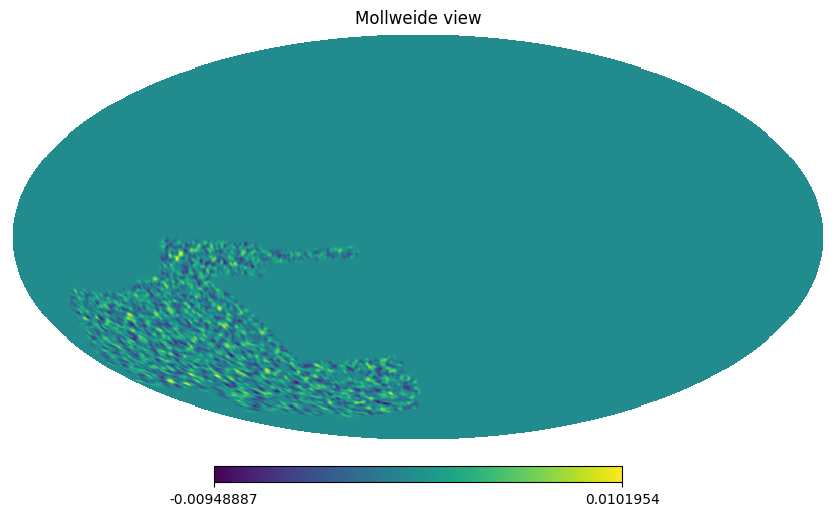

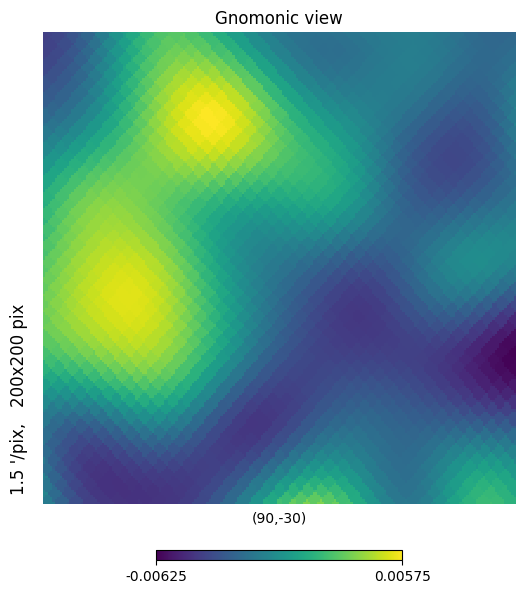

In [50]:
hp_map = np.zeros(n_pix)
hp_map[dv_pix] = dv[i_batch,:,1]
hp_map = hp.reorder(hp_map, n2r=True)

hp_smooth = hp.sphtfunc.smoothing(hp_map, sigma=sigma_rad)

hp.mollview(hp_smooth)
hp.gnomview(hp_smooth, rot=(90, -30, 0))

### tensorflow

In [17]:
# tf_smooth = np.zeros(n_pix_low)
# tf_smooth[dv_pix_low] = dv_low_smoothed[:,0].numpy()
# tf_smooth = hp.ud_grade(tf_smooth, nside_out=512, order_in="NESTED", order_out="NESTED")

# hp.mollview(tf_smooth, nest=True)
# hp.gnomview(tf_smooth, rot=(90, -30, 0), nest=True)

# vmin = tf_smooth.min()
# vmax = tf_smooth.max()

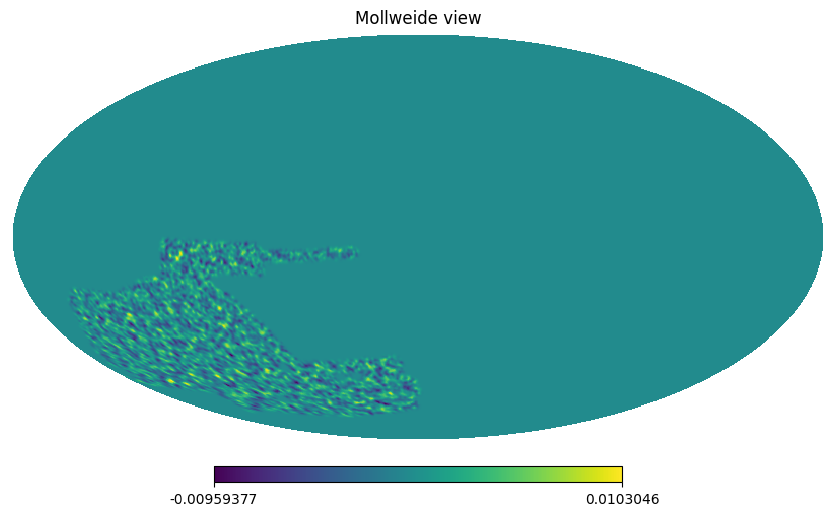

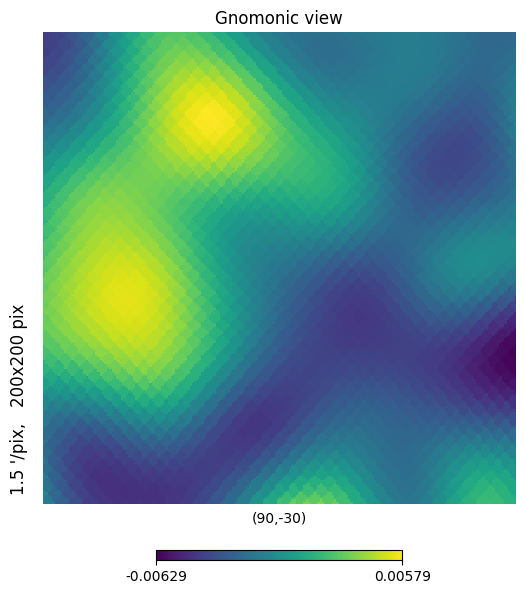

In [48]:
tf_smooth = np.zeros(n_pix)
tf_smooth[dv_pix] = dv_smooth[i_batch,:,1].numpy()

hp.mollview(tf_smooth, nest=True)
hp.gnomview(tf_smooth, rot=(90, -30, 0), nest=True)

vmin = tf_smooth.min()
vmax = tf_smooth.max()

### difference

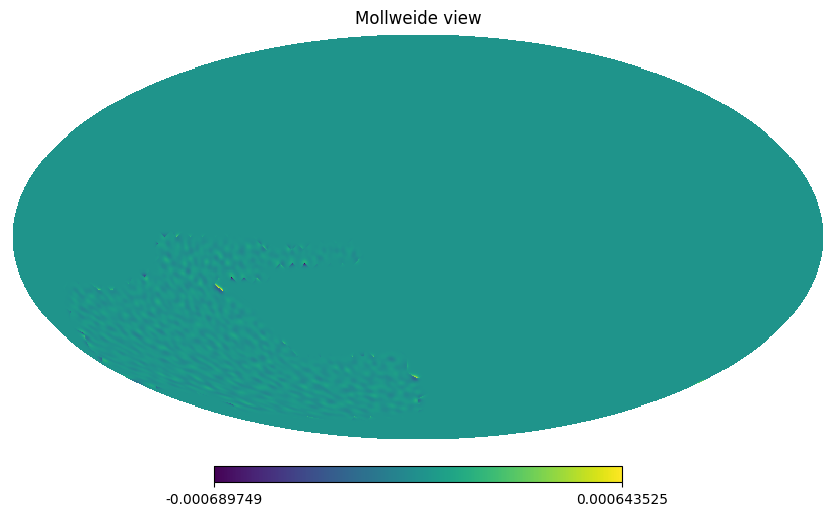

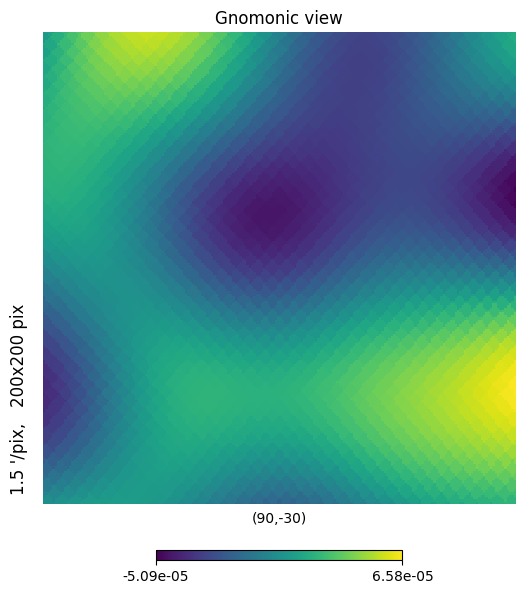

In [47]:
diff_smooth = hp.reorder(hp_smooth, r2n=True) - tf_smooth

# hp.mollview(diff_smooth, nest=True, min=vmin, max=vmax)
# hp.gnomview(diff_smooth, rot=(90, -30, 0), nest=True, min=vmin, max=vmax)

hp.mollview(diff_smooth, nest=True)
hp.gnomview(diff_smooth, rot=(90, -30, 0), nest=True)

In [14]:
# arcmin
fwhm = 22
sigma = 2.355 * fwhm

print(sigma)

51.81
